## Assignment 17 

### Setup

In [14]:
#Gemini API Key
from dotenv import load_dotenv
import os
import base64
import mimetypes
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

# 1. Load the hidden variables from your .env file
load_dotenv()

# 2. Initialize the ChatGoogleGenerativeAI securely using the api_key parameter
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2,
    api_key=os.getenv("ImageSearchEngine")
)

In [15]:
# 3. Helper function to encode image to Base64
def encode_image(image_path):
    """Encodes a local image to base64 string."""
    # https://en.wikipedia.org/wiki/Base64
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [16]:
# 4. The Metadata Function
def generate_search_metadata(image_path, llm, prompt_text):
    """
    Generates a detailed description using LangChain and Gemini.
    """
    try:
        # Determine mime type (e.g., 'image/jpeg', 'image/png')
        mime_type, _ = mimetypes.guess_type(image_path)
        if not mime_type:
            mime_type = 'image/jpeg' # Default fallback

        # Get Base64 string
        img_base64 = encode_image(image_path)

        # Create the Multimodal Message
        # LangChain expects a list of dictionaries for multimodal content
        message = HumanMessage(
            content=[
                {"type": "text", "text": prompt_text},
                {"type": "image_url", "image_url": {"url": f"data:{mime_type};base64,{img_base64}"}}
            ]
        )

        # Invoke the LLM
        response = llm.invoke([message])

        return response.content.replace('```json', '').replace('```', '')

    except FileNotFoundError:
        print(f"Error: The file at {image_path} was not found.")
        return None
    except Exception as e:
        print(f"An error occurred during generation: {e}")
        return None

### The Prompt

In [17]:
image_description_prompt = """
**Role:**
You are an expert Computer Vision Metadata Specialist and SEO Archivist. You possess a deep understanding of visual semantics, image indexing, and natural language retrieval. Your capability involves translating visual data into precise, machine-readable text optimized for search algorithms.

**Context:**
We are building a high-performance multimodal search engine. The metadata you generate will be used to populate a vector database, allowing users to find images using both specific keyword matching and semantic natural language queries (e.g., "a quiet place to work with coffee"). High accuracy and descriptive depth are required to distinguish between similar images.

**Task:**
Analyze the provided image and generate a structured JSON object containing detailed metadata. You must extract the main subject, describe the scene atmospherics, identify visual elements, transcribe specific text, and generate search-optimized keywords.

**Constraints:**

1.  **Description:** Must be objective and factual. Limit to 2-3 sentences. Focus on action, lighting, and mood.
2.  **Text Content:** If no text is visible, return `null`. If text is visible, transcribe it exactly as it appears, preserving case where possible.
3.  **Keywords:** Provide exactly 10-15 keywords. Mix broad concepts (e.g., "urban," "melancholy") with specific objects (e.g., "red umbrella," "taxi").
4.  **Safety:** Do not generate content that violates safety policies. If the image is unclear or blurry, note this in the description.
5.  **Format:** The output must be raw JSON only. Do not include markdown formatting (like ` json ...  `) or conversational filler.

**Examples:**

*Input:* [An image of a golden retriever catching a frisbee in a park on a sunny day]

*Output:*

```json
{
  "main_subject": "Golden Retriever dog",
  "detailed_description": "A golden retriever leaps into the air to catch a red frisbee against a clear blue sky. The lighting is bright and natural, casting sharp shadows on the green grass below. The mood is energetic and playful.",
  "visual_elements": [
    "Golden Retriever",
    "Red Frisbee",
    "Green Grass",
    "Blue Sky",
    "Motion Blur"
  ],
  "text_content": null,
  "search_keywords": [
    "dog",
    "pet",
    "playing",
    "fetch",
    "frisbee",
    "park",
    "sunny",
    "action shot",
    "canine",
    "jumping",
    "outdoor",
    "joyful",
    "golden retriever",
    "summer"
  ]
}
```

**Output Format:**
Generate the response in the following JSON structure:

```json
{
  "main_subject": "String",
  "detailed_description": "String",
  "visual_elements": ["String", "String"],
  "text_content": "String or null",
  "search_keywords": ["String", "String"]
}
```
"""

In [ ]:
import os
import json

source_folder = "Day17_Build Your Own Intelligent Image Search Engine\data\images"
output_folder = "data\jsons"

os.makedirs(output_folder, exist_ok=True)

# Supported image extensions to filter for
valid_extensions = ('.jpg', '.jpeg', '.png', '.webp', '.heic')

print(f"Starting processing for images in: {source_folder}\n")

files = os.listdir(source_folder)
# Calculate total relevant files for the progress counter
total_files = len([f for f in files if f.lower().endswith(valid_extensions)])
processed_count = 0

for filename in files:
    if filename.lower().endswith(valid_extensions):

        image_path = os.path.join(source_folder, filename)

        # Define the output JSON path (same name as image, but .json extension)
        json_filename = f"{os.path.splitext(filename)[0]}.json"
        json_path = os.path.join(output_folder, json_filename)

        if os.path.exists(json_path):
            print(f"[{processed_count + 1}/{total_files}] Skipping: {filename} (JSON already exists)")
            processed_count += 1
            continue

        print(f"[{processed_count + 1}/{total_files}] Generating metadata for: {filename}...")

        try:
            # Call your existing function
            description = generate_search_metadata(image_path, llm, image_description_prompt)

            # Ensure description is parsed to dict if returned as string
            if isinstance(description, str):
                description = json.loads(description)

            if description:
                # Prepare the data structure
                data = {
                    "file_path": image_path,
                    "description": description
                }

                # Write to JSON file
                with open(json_path, 'w', encoding='utf-8') as json_file:
                    json.dump(data, json_file, indent=4)

                print(f"   -> Saved to {json_filename}")
            else:
                print(f"   -> Skipped {filename} (Generation returned empty)")

        except Exception as e:
            print(f"   -> Error processing {filename}: {e}")

        processed_count += 1

print("\n--- Processing Complete ---")

Starting processing for images in: D:\GeeksforGeeks-21_Projects-21_Days-ML-Deep_Learning-and-GenAI\Day17_Build Your Own Intelligent Image Search Engine\data\images

[1/15] Skipping: 3d9d8f4dbf3eaa82be7d7b2db1006503.jpg (JSON already exists)
[2/15] Skipping: a7bf09496ce96327e246b4666f2f6287.jpg (JSON already exists)
[3/15] Skipping: fdbbfadcd52b54dda496d2f61e7151a7.jpg (JSON already exists)
[4/15] Skipping: photo-1636378079382-80f7356df8e3.jpg (JSON already exists)
[5/15] Skipping: photo-1770037368271-ae68da18848b.jpg (JSON already exists)
[6/15] Skipping: photo-1770355302457-10d2b94c2220.jpg (JSON already exists)
[7/15] Skipping: photo-1773332598451-8a0a59941912.jpg (JSON already exists)
[8/15] Skipping: photo-1773332611613-dbdc64f09807.jpg (JSON already exists)
[9/15] Skipping: photo-1773414001281-7e1cadd04a79.jpg (JSON already exists)
[10/15] Skipping: photo-1776179342972-875cbbcdd32f.jpg (JSON already exists)
[11/15] Skipping: photo-1776549821153-070eaa245bc1.jpg (JSON already exist

### Creating Embeddings

In [1]:
import os
import json
import time
from dotenv import load_dotenv
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

load_dotenv()

# 1. Setup
json_folder = "data/jsons"
db_path = "data/chroma_db"

# Initialize Embeddings
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001", api_key=os.getenv("GENAI_API_KEY"))

# 2. Check if DB exists before doing heavy lifting
# We check if the folder exists and is not empty (Chroma creates files inside)
db_exists = os.path.exists(db_path) and os.listdir(db_path)

if db_exists:
    print(f"Database found at {db_path}. Loading existing VectorStore...")
    vectorstore = Chroma(
        persist_directory=db_path,
        embedding_function=embeddings
    )
    print(f"Loaded existing DB with {vectorstore._collection.count()} documents.")

else:
    print("Database not found. Starting ingestion process...")

    # Load ALL JSONs into a list of Documents first (No API calls here)
    documents = []

    if os.path.exists(json_folder):
        files = [f for f in os.listdir(json_folder) if f.endswith('.json')]
        print(f"Found {len(files)} JSON files. Preparing data...")

        for filename in files:
            file_path = os.path.join(json_folder, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                desc_obj = data.get("description", {})

                # Construct Context
                text_content = f"""
                Subject: {desc_obj.get('main_subject', 'Unknown')}
                Description: {desc_obj.get('detailed_description', '')}
                Keywords: {', '.join(desc_obj.get('search_keywords', []))}
                Visual Elements: {', '.join(desc_obj.get('visual_elements', []))}
                """

                doc = Document(
                    page_content=text_content,
                    metadata={
                        "file_name": data.get("file_name", filename),
                        "file_path": data.get("file_path", "")
                    }
                )
                documents.append(doc)
    else:
        print("JSON folder not found.")

    # 3. Add to Chroma in Batches with Timeout
    if documents:
        print(f"Loaded {len(documents)} documents. Starting ingestion with rate limits...")

        # Initialize the DB (This creates the folder)
        vectorstore = Chroma(
            persist_directory=db_path,
            embedding_function=embeddings
        )

        BATCH_SIZE = 5
        total_batches = (len(documents) + BATCH_SIZE - 1) // BATCH_SIZE

        for i in range(0, len(documents), BATCH_SIZE):
            batch = documents[i : i + BATCH_SIZE]
            current_batch_num = (i // BATCH_SIZE) + 1

            print(f"Processing Batch {current_batch_num}/{total_batches} ({len(batch)} docs)...")

            # A. Add documents (This triggers the API Call)
            vectorstore.add_documents(batch)

            # B. Wait if this is not the last batch
            if i + BATCH_SIZE < len(documents):
                print("   -> Waiting 60 seconds to respect rate limits...")
                time.sleep(60)

        print(f"\nSuccess! All documents saved to: {db_path}")

    else:
        print("No documents to process.")

Database not found. Starting ingestion process...
Found 13 JSON files. Preparing data...
Loaded 13 documents. Starting ingestion with rate limits...
Processing Batch 1/3 (5 docs)...
   -> Waiting 60 seconds to respect rate limits...
Processing Batch 2/3 (5 docs)...
   -> Waiting 60 seconds to respect rate limits...
Processing Batch 3/3 (3 docs)...

Success! All documents saved to: data/chroma_db


Database loaded successfully!
Match #1
File: 3d9d8f4dbf3eaa82be7d7b2db1006503.json
Context: 
                Subject: Motorcyclist and sport motorcycle
                Description: A person in...


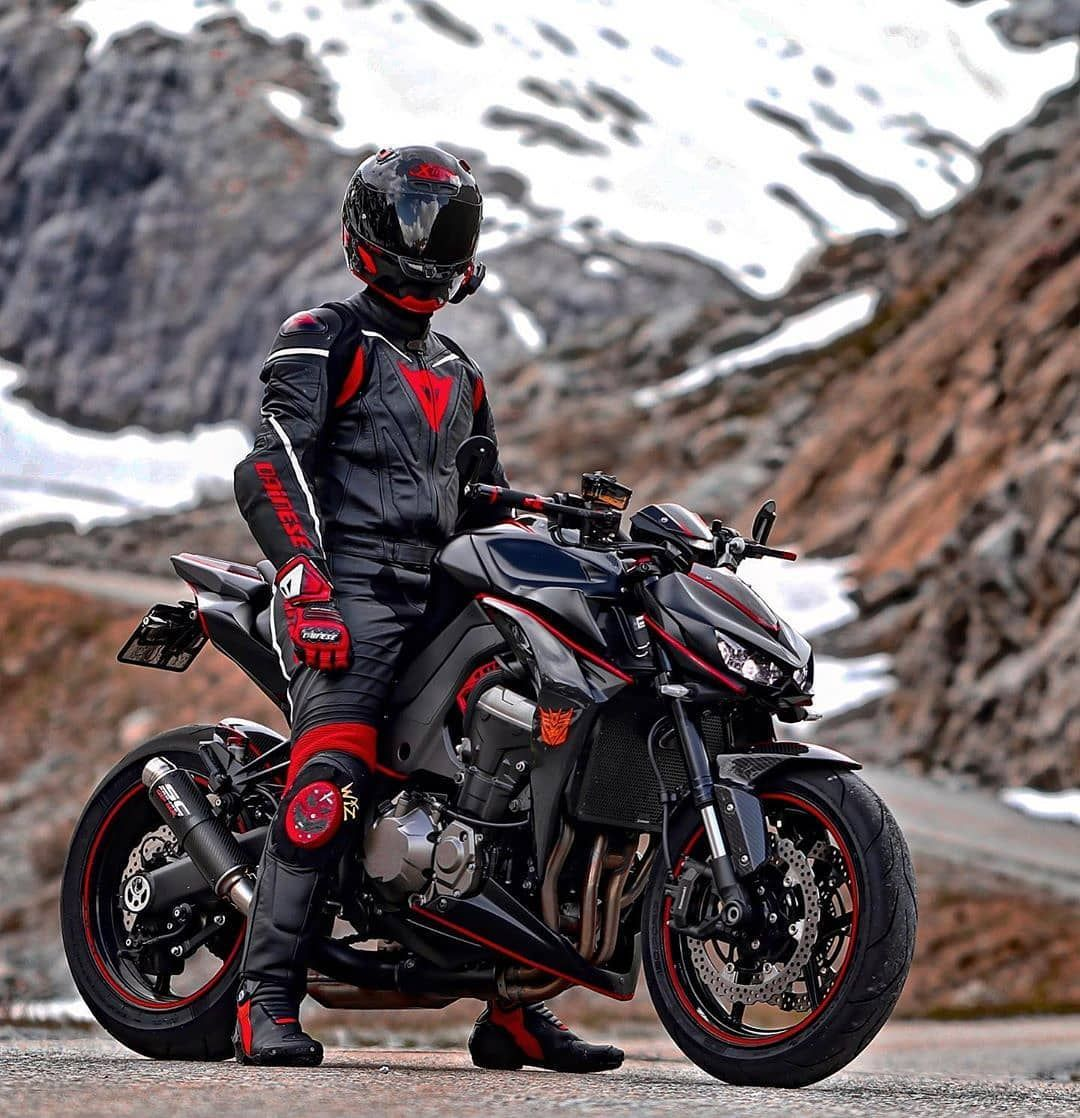

----------------------------------------
Match #2
File: photo-1773332598451-8a0a59941912.json
Context: 
                Subject: Young adult working or studying on a bed
                Description: A yo...


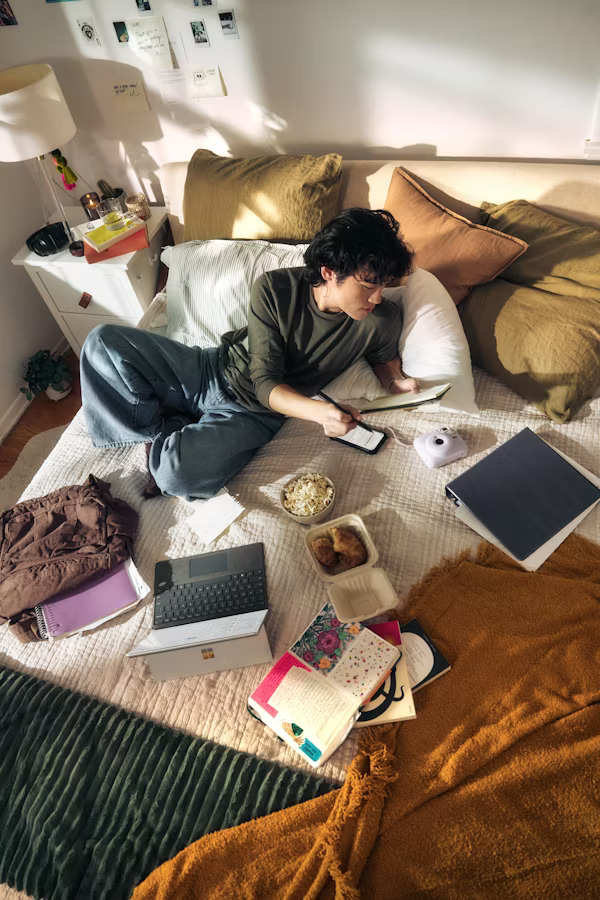

----------------------------------------
Match #3
File: photo-1770355302457-10d2b94c2220.json
Context: 
                Subject: Person walking in an urban street
                Description: A person wa...


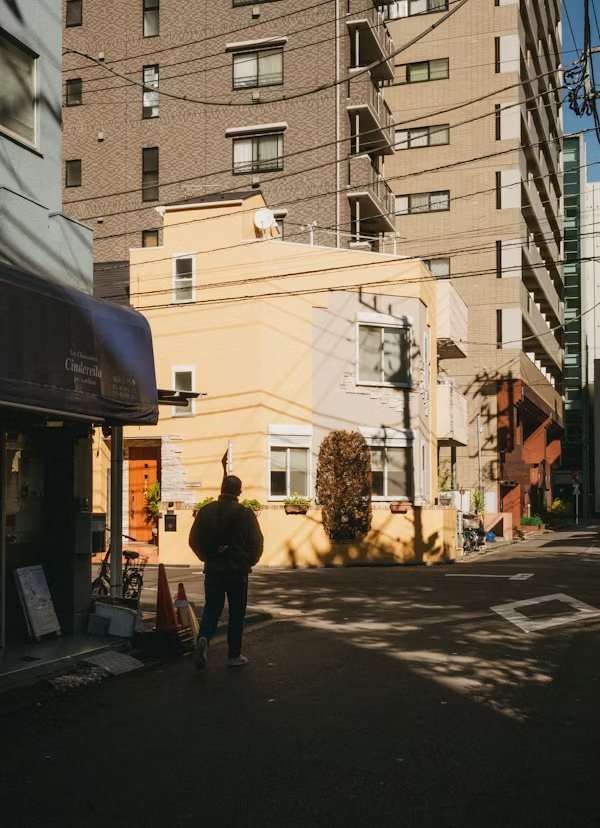

----------------------------------------


In [2]:
import os
from langchain_chroma import Chroma
from dotenv import load_dotenv
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from IPython.display import display, Image

load_dotenv()


db_path = "data/chroma_db"

# IMPORTANT: Must use the exact same model name you used to create the DB
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001", api_key=os.getenv("GENAI_API_KEY"))

# Load the Database
# We point to the persist_directory to load the existing index
vectorstore = Chroma(
    persist_directory=db_path,
    embedding_function=embeddings
)

print("Database loaded successfully!")

def search_images(query, top_k=3):
    """
    Searches the vector DB for images matching the text query.
    """

    # Perform Similarity Search
    # This embeds the query and finds the 'top_k' closest vectors
    results = vectorstore.similarity_search(query, k=top_k)

    if not results:
        print("No matches found.")
        return None

    # Display Results
    for i, doc in enumerate(results):
        file_path = doc.metadata.get("file_path")
        subject = doc.metadata.get("main_subject")
        file_name = doc.metadata.get("file_name")

        print(f"Match #{i+1}")
        print(f"File: {file_name}")
        print(f"Context: {doc.page_content[:100]}...") # Show first 100 chars of description

        # Display the actual image
        if os.path.exists(file_path):
            display(Image(filename=file_path, width=300))
        else:
            print(f"Image file not found at: {file_path}")

        print("-" * 40)


# Example 1: Conceptual search
search_images("man")

Match #1
File: fdbbfadcd52b54dda496d2f61e7151a7.json
Context: 
                Subject: Black KTM Duke motorcycle
                Description: A sleek black naked...


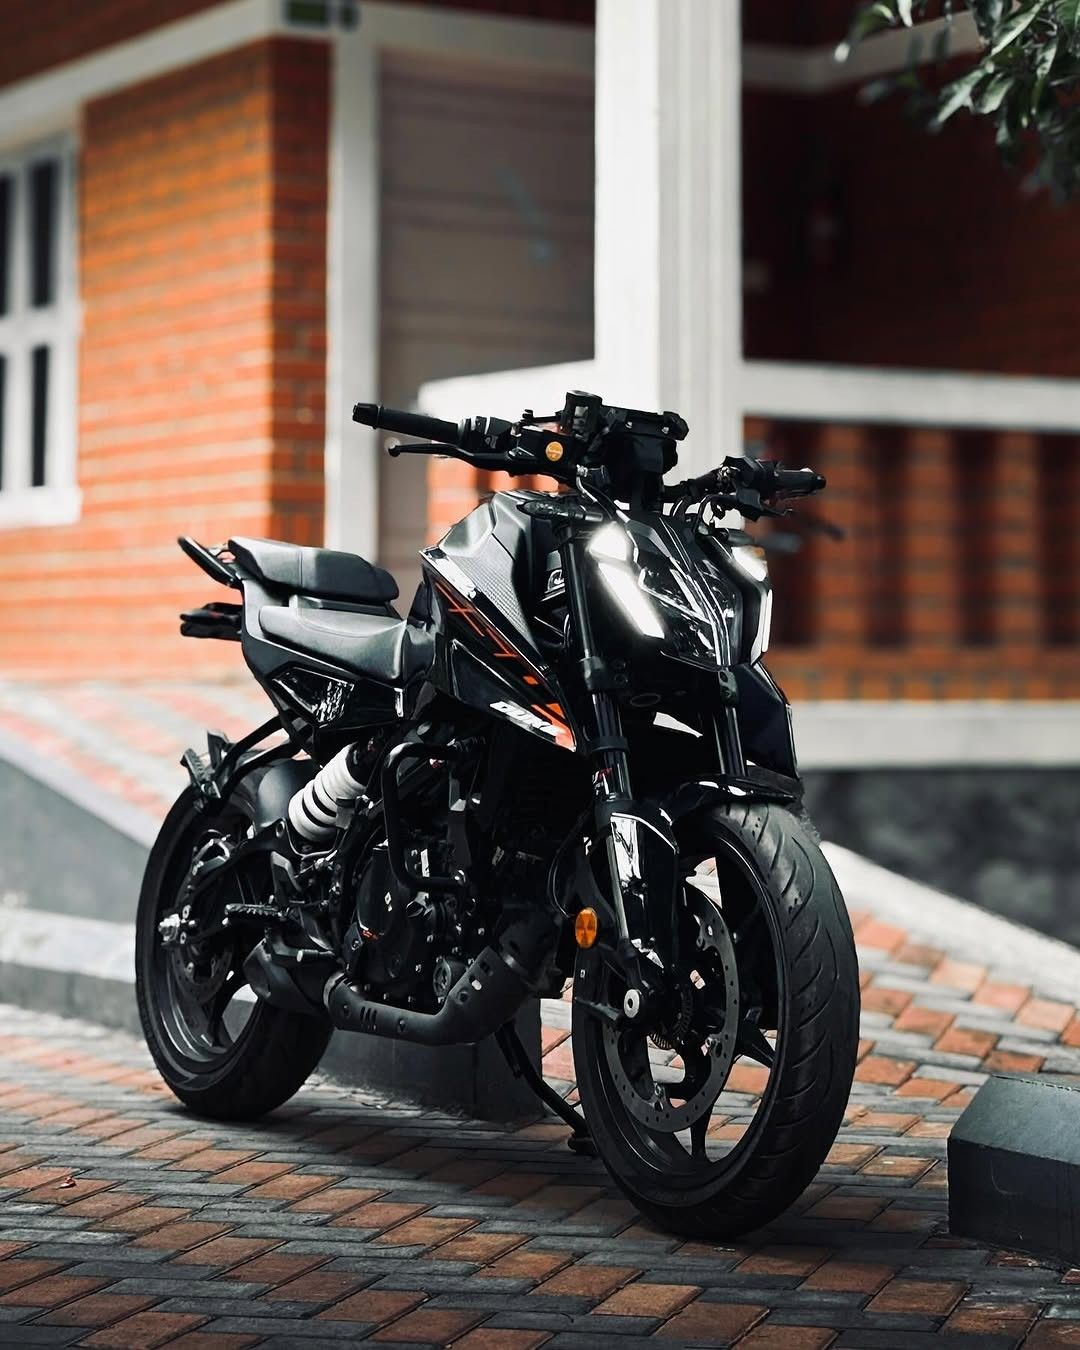

----------------------------------------
Match #2
File: a7bf09496ce96327e246b4666f2f6287.json
Context: 
                Subject: KTM Super Duke R motorcycle
                Description: A high-performanc...


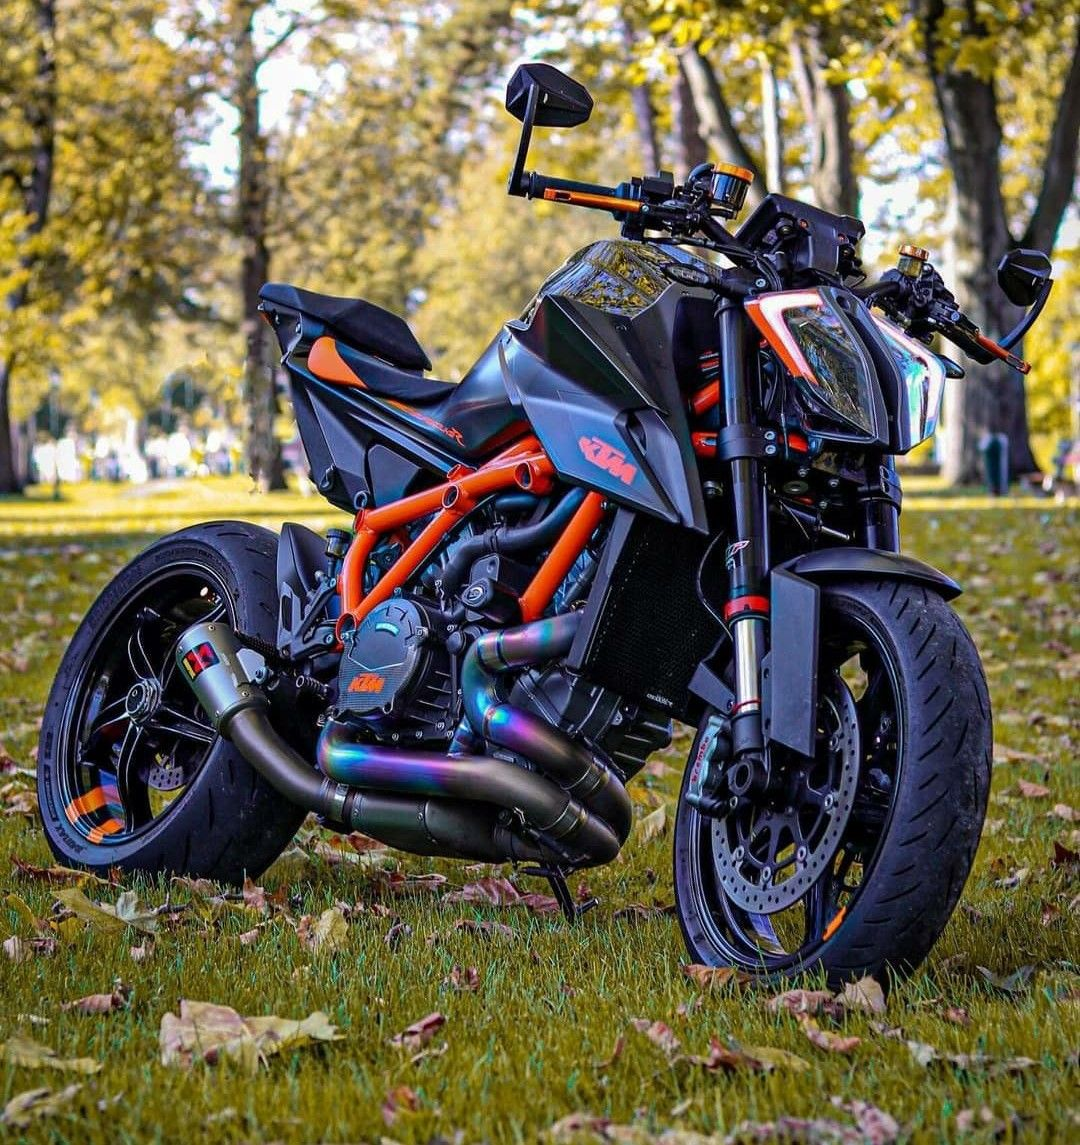

----------------------------------------
Match #3
File: 3d9d8f4dbf3eaa82be7d7b2db1006503.json
Context: 
                Subject: Motorcyclist and sport motorcycle
                Description: A person in...


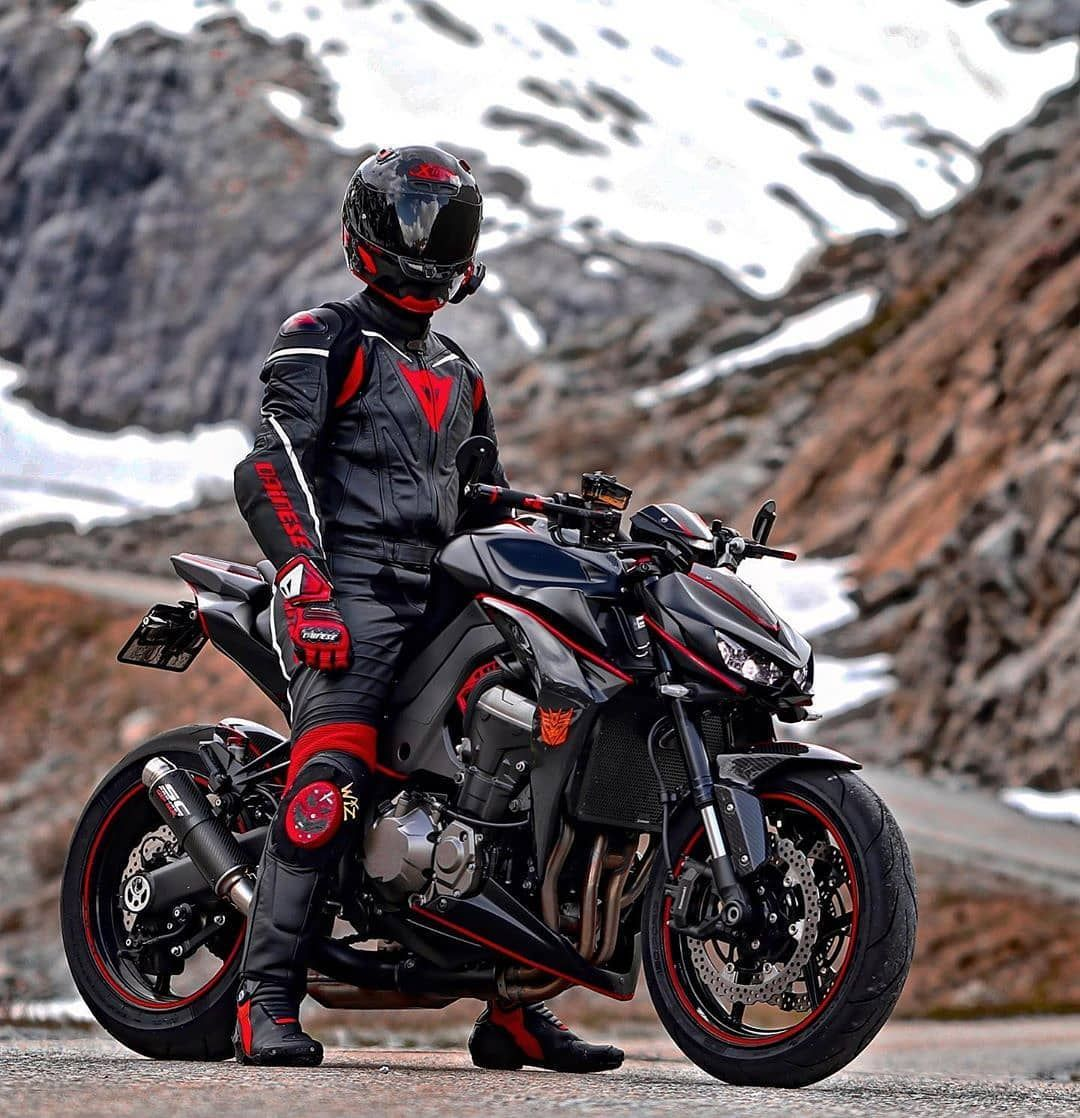

----------------------------------------


In [3]:
search_images("bike")